In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BPBstate(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr : float
    bpb : float
    boundary_percent : float

    summary : str

In [3]:
def calculate_sr(state: BPBstate):
    runs = state['runs']
    balls = state['balls']
    sr = (runs/balls)*100
    return {'sr':sr}

def calculate_bpb(state: BPBstate):
    balls = state['balls']
    fours = state['fours']
    sixes = state['sixes']
    bpb =  balls/(fours+sixes)
    return {'bpb':bpb}

def calculate_boundary_percent(state: BPBstate):
    runs = state['runs']
    fours = state['fours']
    sixes = state['sixes']
    boundary_percent =  (((fours* 4) + (sixes*6))/runs )* 100
    return {'boundary_percent':boundary_percent}


def get_summary(state: BPBstate):
    sr = round(state['sr'],2)
    bpb = round(state['bpb'],2)
    boundary_percent = round(state['boundary_percent'],2)

    summary = f"This match was fabulous, with an strike rate of {sr} and the balls per boudary is {bpb} and the boundary percentage was {boundary_percent}"
    return {'summary':summary}
    

In [4]:
graph = StateGraph(BPBstate)

In [5]:
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('get_summary', get_summary)

In [6]:
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'get_summary')
graph.add_edge('calculate_bpb', 'get_summary')
graph.add_edge('calculate_boundary_percent', 'get_summary')

graph.add_edge('get_summary', END)

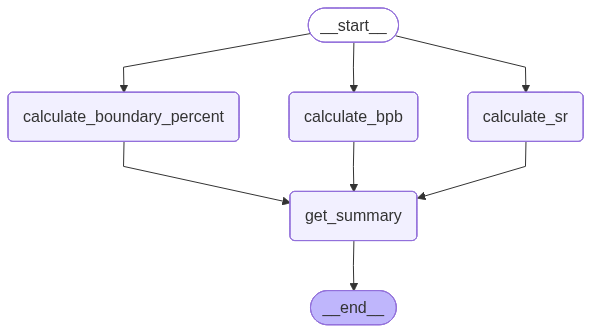

In [7]:
workflow = graph.compile()

workflow

In [8]:
initial_state = {'runs': 265, 'balls':120, 'fours':20, 'sixes':20}

final_state = workflow.invoke(initial_state)

In [9]:
print(final_state['sr'])

220.83333333333334


In [10]:
print(final_state['bpb'])

3.0


In [11]:
print(final_state['boundary_percent'])

75.47169811320755


In [12]:
print(final_state['summary'])

This match was fabulous, with an strike rate of 220.83 and the balls per boudary is 3.0 and the boundary percentage was 75.47
